<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/pytorch/11_softmax%20and%20Entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

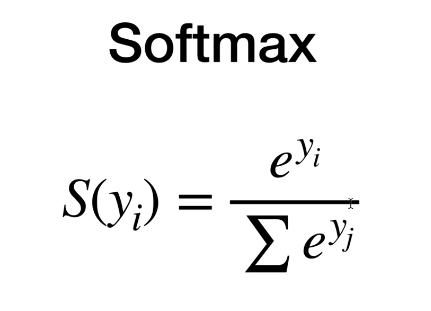

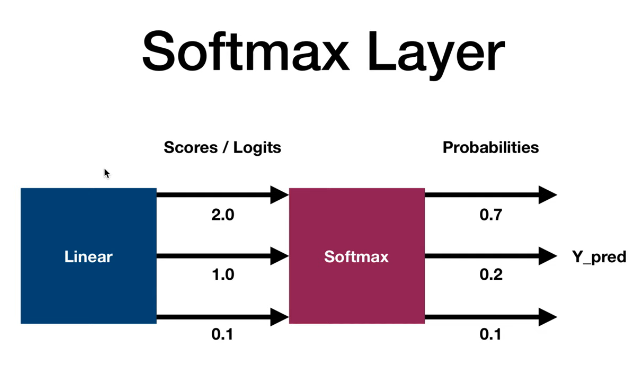

In [24]:
import torch
import torch.nn as nn
import numpy as np


In [25]:
def softmax(x):
  return np.exp(x) / np.sum(np.exp(x), axis=0)


In [26]:
x = np.array([2.0, 1.0, 0.1])
outputs =softmax(x)
print("softmax numpy : ", outputs)

softmax numpy :  [0.65900114 0.24243297 0.09856589]


In [27]:
x = torch.tensor([2.0, 1.0, 0.1])
outputs = torch.softmax(x, dim=0)
print(outputs)

tensor([0.6590, 0.2424, 0.0986])


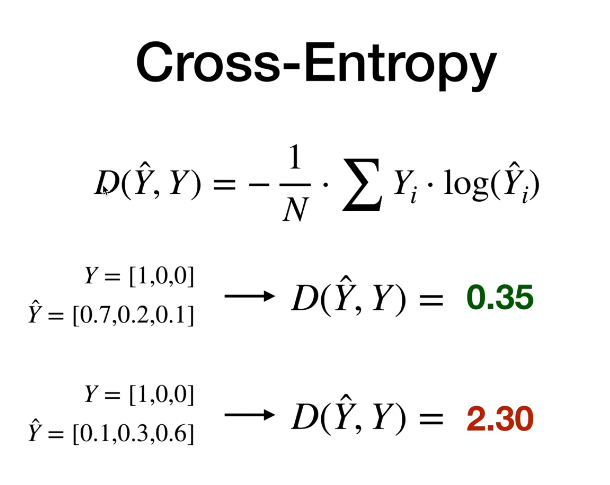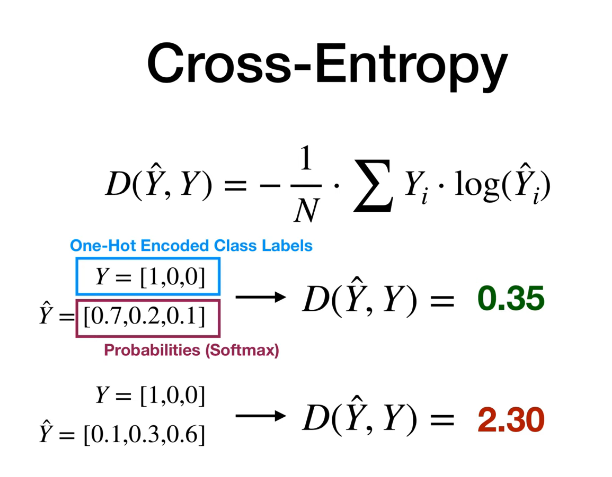

In [28]:
import torch
import torch.nn as nn
import numpy as np


def cross_entropy(actual, predicted):
  loss = -np.sum(actual*np.log(predicted))
  return loss # / float(predicted.shape[0])

In [29]:
# y must be one hot encoded
# if class 0 : [1 0 0]
# if class 1 : [0 1 0]
# if class 2 : [0 0 1]

y = np.array([1,0,0])

# y_pred has probabilities

y_pred_good = np.array([0.7,0.2,0.1])
y_pred_bad = np.array([0.1,0.3,0.6])

l1 = cross_entropy(y,y_pred_good)
l2 = cross_entropy(y,y_pred_bad)

print(f'Loss1 numpy: {l1:.4f}')
print(f'Loss2 numpy: {l2:.4f}')


Loss1 numpy: 0.3567
Loss2 numpy: 2.3026


for Binary_class

In [30]:
import torch
import torch.nn as nn
import numpy as np


In [33]:
loss = nn.CrossEntropyLoss()

Y = torch.tensor([0])
# nsamples x nclasses = 1X3
y_pred_good = torch.tensor([[2.0, 1.0, 0.1]])
y_pred_bad = torch.tensor([[0.5, 2.0, 0.3]])


l1 = loss(y_pred_good, Y)
l2 = loss(y_pred_bad, Y)

print(l1.item())
print(l2.item())


0.4170299470424652
1.840616226196289


In [35]:
_, predictions1 = torch.max(y_pred_good,1)
_, predictions2 = torch.max(y_pred_bad,1)

print(predictions1)
print(predictions2)

tensor([0])
tensor([1])


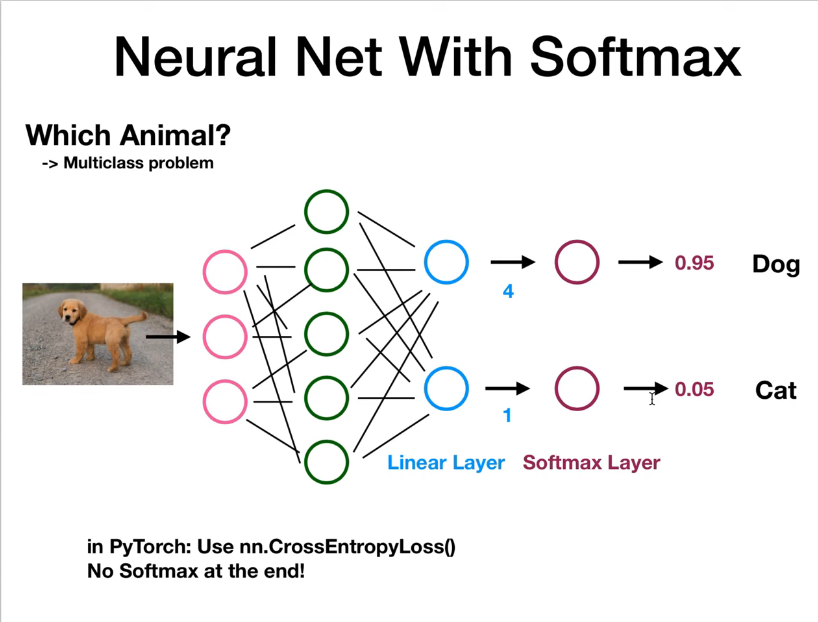

In [2]:
import torch
import torch.nn as nn

# multiclass problem
class NeuralNet2(nn.Module):

  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNet2, self).__init__()
    self.linear1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.linear1(x)
    out = self.relu(out)
    out = self.linear2(out)

    # no softmax at the end
    return out

model = NeuralNet2(input_size=28*28 , hidden_size=5, num_classes=3)
criterion = nn.CrossEntropyLoss() # applies Softmax